In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd()))

from src.data_cleaning import (  load_data,inspect_structure, inspect_missing_values, inspect_duplicates, inspect_memory_usage, 
                               inspect_unique_values, inspect_numerical_summary, handle_missing_values,
    remove_duplicates, optimize_data_types, clean_inconsistent_values, detect_outliers_iqr, validate_cleaned_data, get_memory_usage,
      clean_dataset
)
from src.feature_engineering import engineer_features
from src.data_analysis import analyze_data
from src.visualization import ( plot_category_performance, plot_profit_by_subcategory, plot_regional_performance,  plot_city_performance,
 plot_discount_vs_profit_margin, plot_sales_seasonality, plot_profit_distribution, plot_profit_by_region_category
)

## 1. Data Loading

Load the raw dataset using a reusable data loading function.

In [2]:
file_path = r"C:\Users\DELL\Downloads\Sample - Superstore 2019 (1).xls"

df = load_data(file_path)

Dataset loaded successfully.


In [3]:
df.shape

(9994, 21)

## 2. Data Inspection

Before applying any cleaning operations, the dataset is inspected to understand its structure, data types, missing values, duplicate records, memory usage, unique values, and numerical characteristics.

### Dataset Structure

In [4]:
inspect_structure(df)

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit             

### Missing Values

In [5]:
inspect_missing_values(df)

,Missing Count
Postal Code,11


### Duplicate Records

In [6]:
inspect_duplicates(df)

np.int64(0)

### Memory Usage

In [7]:
inspect_memory_usage(df)

,Memory Usage (bytes)
Product Name,449496
Product ID,229862
Order ID,219868
Country/Region,209874
Customer Name,209570
Ship Mode,208106
Category,207901
City,173203
Segment,168273
State,164773


### Unique Values

In [8]:
inspect_unique_values(df)

,Unique Values
Country/Region,1
Segment,3
Category,3
Ship Mode,4
Region,4
Discount,12
Quantity,14
Sub-Category,17
State,49
City,531


### Numerical Summary

In [9]:
inspect_numerical_summary(df)

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2018-04-30 10:03:51.979187,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,2018-05-04 09:03:29.645787,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Postal Code,9983.0,55245.233297,1040.0,23223.0,57103.0,90008.0,99301.0,32038.715955
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108


## Data Cleaning



### Memory Optimization

In [10]:
memory_before = get_memory_usage(df)

print(f"Memory Before Cleaning: {memory_before:.2f} MB")

Memory Before Cleaning: 3.17 MB


In [11]:
df = clean_dataset(df)

No duplicate records found.


In [12]:
print(df.dtypes)

Row ID                     int16
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode               category
Customer ID                  str
Customer Name                str
Segment                 category
Country/Region          category
City                         str
State                        str
Postal Code                Int64
Region                  category
Product ID                   str
Category                category
Sub-Category            category
Product Name                 str
Sales                    float64
Quantity                    int8
Discount                 float32
Profit                   float32
dtype: object


In [13]:
memory_after = get_memory_usage(df)

print(f"Memory After Cleaning: {memory_after:.2f} MB")

Memory After Cleaning: 2.02 MB


In [14]:
memory_reduction = memory_before - memory_after
percentage_reduction = (
    memory_reduction / memory_before
) * 100

print(f"Memory Reduced: {memory_reduction:.2f} MB")
print(f"Memory Reduction: {percentage_reduction:.2f}%")

Memory Reduced: 1.15 MB
Memory Reduction: 36.29%


### Checking Missing Postal Codes

In [15]:
postal_nulls = df[df["Postal Code"].isna()]

postal_nulls[
    ["Country/Region", "State", "City", "Postal Code"]
]

,Country/Region,State,City,Postal Code
2234,United States,Vermont,Burlington,<NA>
5274,United States,Vermont,Burlington,<NA>
8798,United States,Vermont,Burlington,<NA>
9146,United States,Vermont,Burlington,<NA>
9147,United States,Vermont,Burlington,<NA>
9148,United States,Vermont,Burlington,<NA>
9386,United States,Vermont,Burlington,<NA>
9387,United States,Vermont,Burlington,<NA>
9388,United States,Vermont,Burlington,<NA>
9389,United States,Vermont,Burlington,<NA>


In [16]:
postal_nulls.groupby(
    ["Country/Region", "State", "City"],
    dropna=False
).size().sort_values(ascending=False)

Country/Region  State    City      
United States   Vermont  Burlington    11
dtype: int64

### Handling Missing Postal Codes

In [17]:
df.loc[
    (df["City"] == "Burlington") &
    (df["State"] == "Vermont") &
    (df["Postal Code"].isna()),
    "Postal Code"
] = 5401

In [18]:
df["Postal Code"].isna().sum()

np.int64(0)

###  Outlier Detection

In [19]:
outlier_summary = detect_outliers_iqr(
    df,
    columns=[
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Sales,17.28000,209.940,192.66000,-271.710000,498.930000,1167
1,Quantity,2.00000,5.000,3.00000,-2.500000,9.500000,170
2,Discount,0.00000,0.200,0.20000,-0.300000,0.500000,856
3,Profit,1.72875,29.364,27.63525,-39.724125,70.816876,1881


###  Data Validation

In [20]:
validate_cleaned_data(df)


Rows                 9994
Columns                21
Missing Values          0
Duplicate Records       0
Negative Sales          0
Negative Quantity       0
Invalid Discount        0
dtype: int64

### Final Data Types

In [21]:
print("Final Data Types:")
print(df.dtypes)

print(f"\nFinal Dataset Shape: {df.shape}")

print(f"Final Memory Usage: {get_memory_usage(df):.2f} MB")

Final Data Types:
Row ID                     int16
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode               category
Customer ID                  str
Customer Name                str
Segment                 category
Country/Region          category
City                         str
State                        str
Postal Code                Int64
Region                  category
Product ID                   str
Category                category
Sub-Category            category
Product Name                 str
Sales                    float64
Quantity                    int8
Discount                 float32
Profit                   float32
dtype: object

Final Dataset Shape: (9994, 21)
Final Memory Usage: 2.02 MB


### Final Memory Usage

In [22]:
memory_final = get_memory_usage(df)

print(f"Final Memory Usage: {memory_final:.2f} MB")

Final Memory Usage: 2.02 MB


## Feature Engineering

In [23]:
df = engineer_features(df)

In [24]:
df[
    [
        "Sales",
        "Profit",
        "Profit Margin",
        "Order Date",
        "Ship Date",
        "Shipping Duration",
        "Sales Performance Category"
    ]
].head()

,Sales,Profit,Profit Margin,Order Date,Ship Date,Shipping Duration,Sales Performance Category
0,261.9600,41.913601,0.1600,2018-11-08,2018-11-11,3,High
1,731.9400,219.582001,0.3000,2018-11-08,2018-11-11,3,High
2,14.6200,6.871400,0.4700,2018-06-12,2018-06-16,4,Low
3,957.5775,-383.031006,-0.4000,2017-10-11,2017-10-18,7,High
4,22.3680,2.516400,0.1125,2017-10-11,2017-10-18,7,Low


### Data Analysis

In [25]:
analysis_results = analyze_data(df)

In [26]:
analysis_results["category_performance"]


,Sales,Profit
Category,,
Technology,836154.0330,145454.953125
Furniture,741999.7953,18451.273438
Office Supplies,719047.0320,122490.804688


In [27]:
analysis_results["profit_by_subcategory"]


Sub-Category
Copiers        55617.824219
Phones         44515.730469
Accessories    41936.636719
Paper          34053.570312
Binders        30221.763672
Chairs         26590.166016
Storage        21278.826172
Appliances     18138.005859
Furnishings    13059.143555
Envelopes       6964.176758
Art             6527.787109
Labels          5546.253906
Machines        3384.756836
Fasteners        949.518188
Supplies       -1189.099487
Bookcases      -3472.556152
Tables        -17725.480469
Name: Profit, dtype: float32

In [28]:
analysis_results["regional_performance"]


,Sales,Profit
Region,,
West,725457.8245,108418.445312
East,678781.2400,91522.781250
Central,501239.8908,39706.363281
South,391721.9050,46749.429688


In [29]:
analysis_results["city_performance"]


,Sales,Profit
City,,
New York City,256368.1610,62036.984375
Los Angeles,175851.3410,30440.757812
Seattle,119540.7420,29156.097656
San Francisco,112669.0920,17507.384766
Philadelphia,109077.0130,-13837.767578
Houston,64504.7604,-10153.548828
Chicago,48539.5410,-6654.568848
San Diego,47521.0290,6377.195801
Jacksonville,44713.1830,-2323.834961


In [30]:
analysis_results["sales_seasonality"]

Order Date
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

In [31]:
analysis_results["discount_vs_profit_margin"]


,Discount,Profit Margin
0,0.00,0.1600
1,0.00,0.3000
2,0.00,0.4700
3,0.45,-0.4000
4,0.20,0.1125
...,...,...
9989,0.20,0.1625
9990,0.00,0.1700
9991,0.20,0.0750
9992,0.00,0.4500


In [32]:
analysis_results["sales_seasonality"]


Order Date
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

In [33]:
analysis_results["profit_distribution_by_category"]


,Category,Profit
0,Furniture,41.913601
1,Furniture,219.582001
2,Office Supplies,6.871400
3,Furniture,-383.031006
4,Office Supplies,2.516400
...,...,...
9989,Furniture,4.102800
9990,Furniture,15.633200
9991,Technology,19.393200
9992,Office Supplies,13.320000


In [34]:
analysis_results["profit_by_region_category"]

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.049316,8879.980469,33697.429688
East,3046.165527,41014.578125,47462.035156
South,6771.206055,19986.392578,19991.832031
West,11504.950195,52609.847656,44303.648438


### Data Visualization

### Question 1 (Category Performance)

**Which categories generate the strongest combination of sales and profit?**

This analysis compares total sales and profit across product categories to identify which categories contribute most strongly to the company's overall financial performance.

<Figure size 900x600 with 0 Axes>

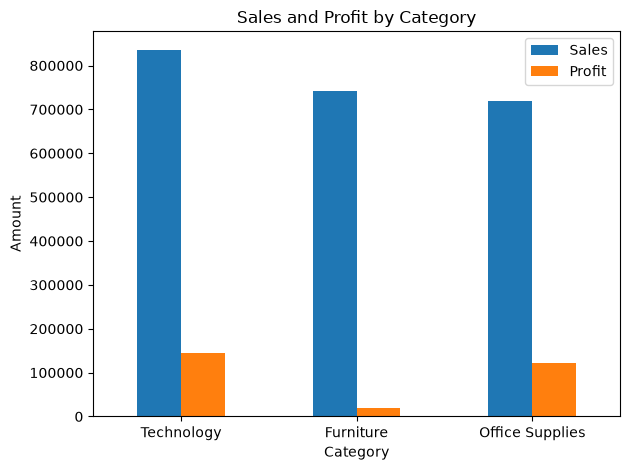

In [35]:
plot_category_performance(
    analysis_results["category_performance"]
)

### Question 2 (Sub-Category Profitability)

**Which sub-categories are the most and least profitable?**

This analysis ranks sub-categories based on total profit to identify the strongest contributors to profitability and the areas that may require further investigation.

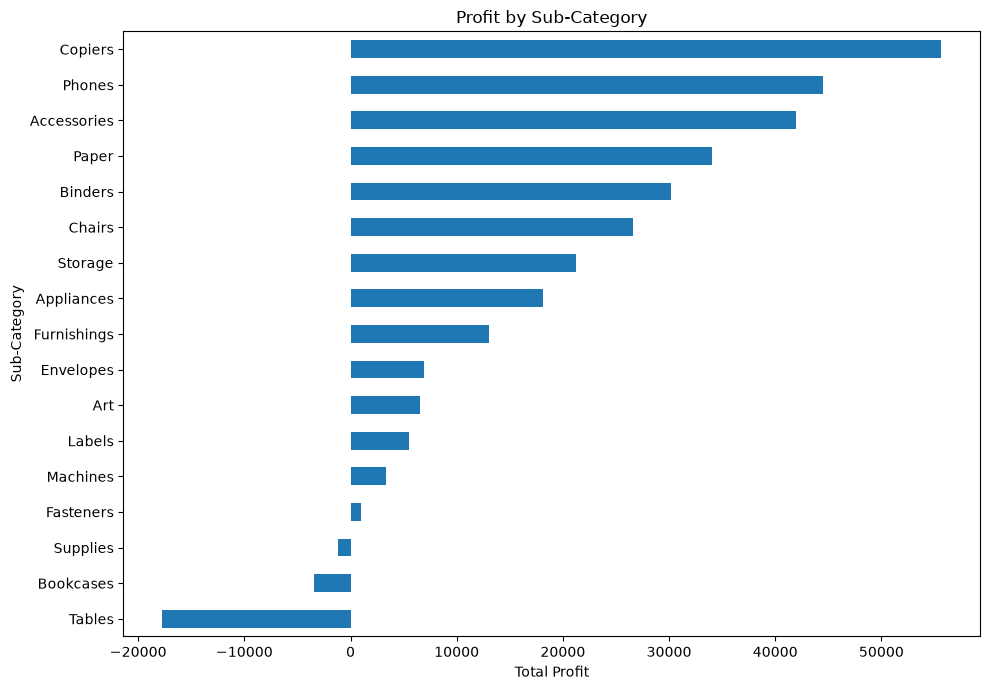

In [36]:
plot_profit_by_subcategory(
    analysis_results["profit_by_subcategory"]
)

### Question 3 (Regional Sales vs Profit)

**Are the regions generating the highest sales also generating the highest profit?**

This analysis examines the relationship between sales and profit across regions to determine whether strong revenue performance is consistently associated with strong profitability.

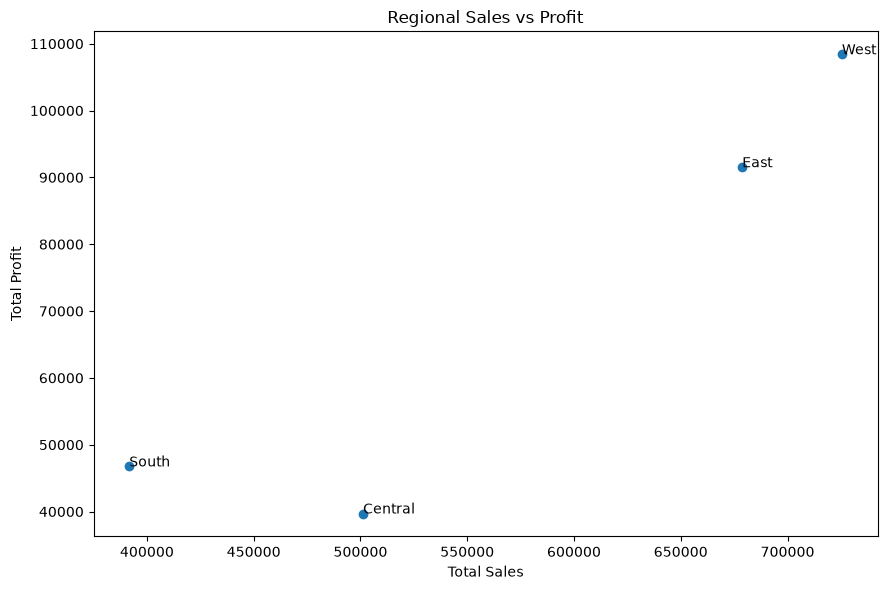

In [37]:
plot_regional_performance(
    analysis_results["regional_performance"]
)

### Business Question 4 (City Performance)

**Which cities generate the highest sales and profit?**

This analysis identifies the top-performing cities based on sales and profit to determine which geographic markets contribute most to the company's performance.

<Figure size 1000x800 with 0 Axes>

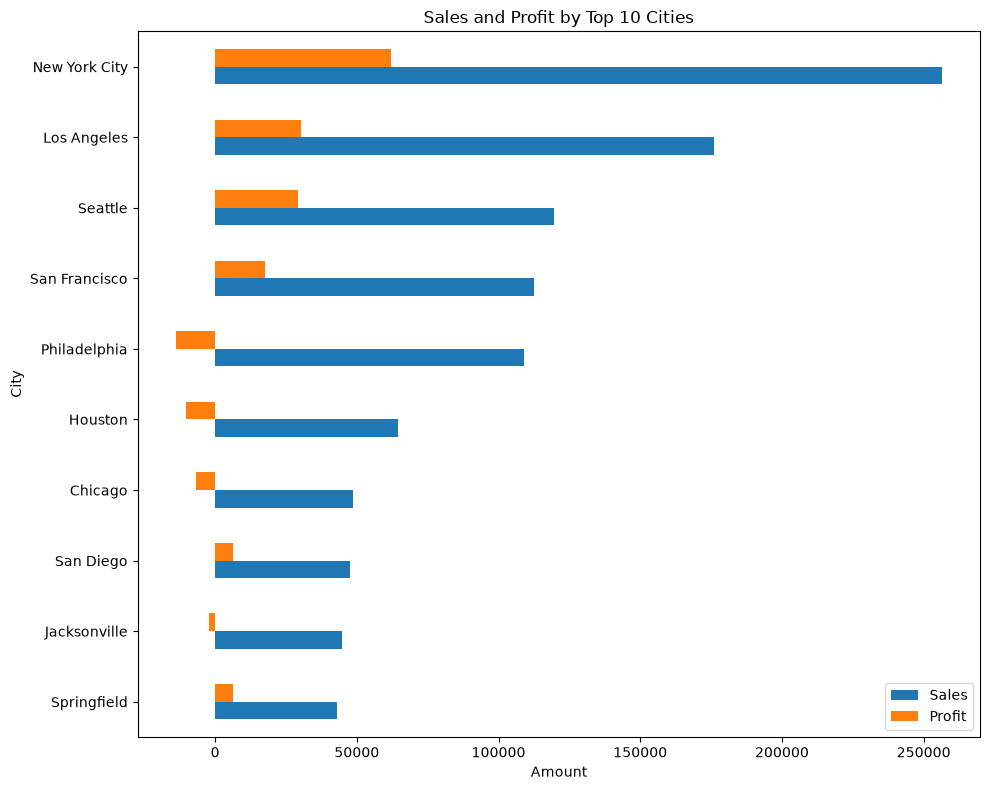

In [38]:
plot_city_performance(
    analysis_results["city_performance"]
)

### Business Question 5 (Discount vs Profit Margin)

**Does discount level affect profit margin?**

This analysis investigates the relationship between discount levels and profit margin to evaluate whether increasing discounts may negatively affect the company's profitability.

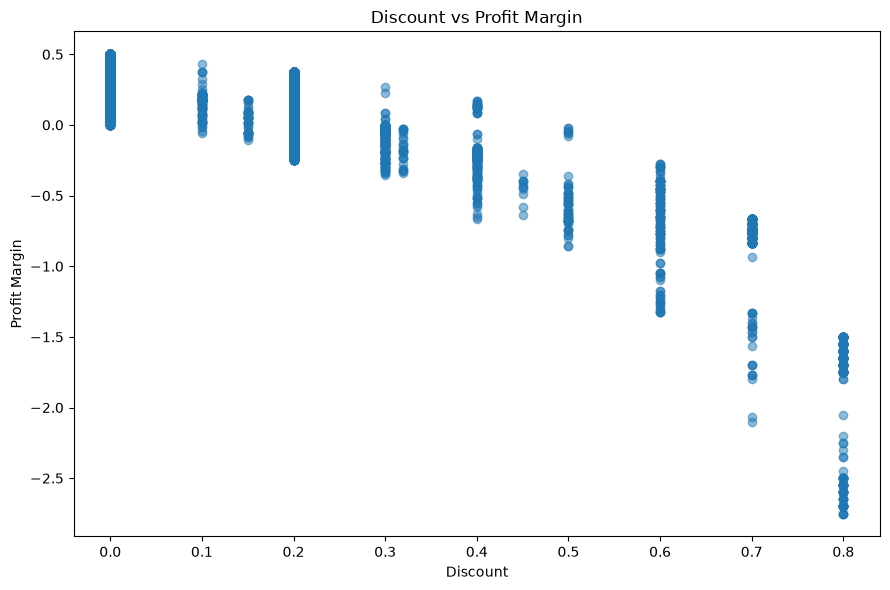

In [39]:
plot_discount_vs_profit_margin(
    analysis_results["discount_vs_profit_margin"]
)

### Question 6 — Sales Seasonality

**Which months generate the highest and lowest sales across all years?**

This analysis compares sales across calendar months to identify recurring seasonal patterns and determine which months experience the highest and lowest levels of customer demand.

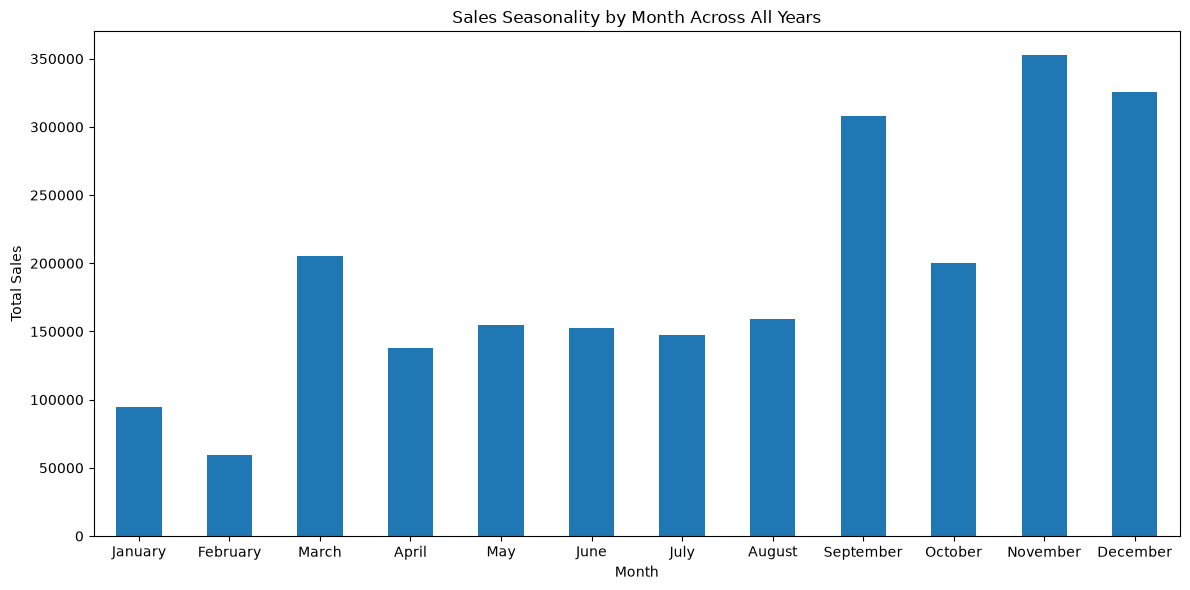

In [40]:
plot_sales_seasonality(
    analysis_results["sales_seasonality"]
)

### Question 7 (Profit Distribution by Category)

**Which categories have the most variable profitability?**

This analysis compares the distribution of profit across categories to identify differences in profitability consistency, spread, and extreme values.

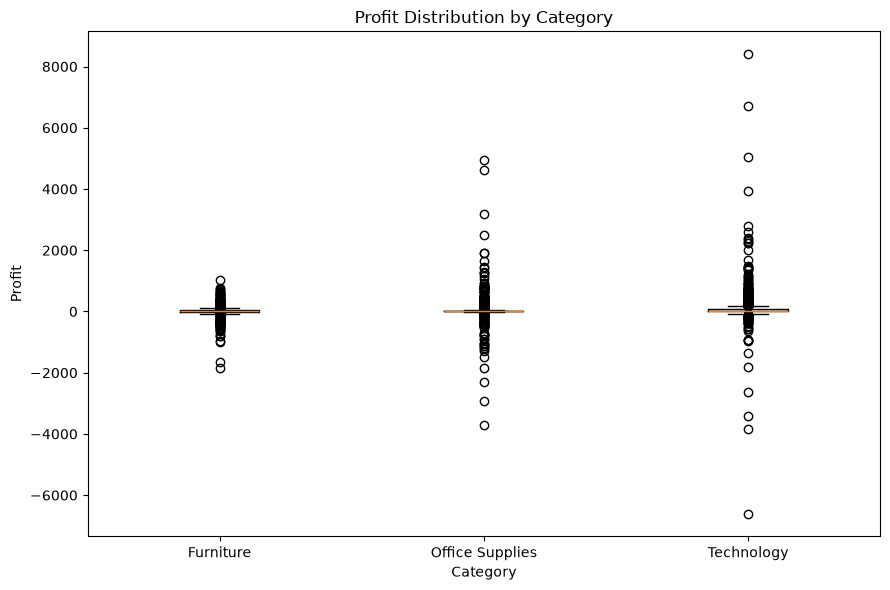

In [41]:
plot_profit_distribution(
    analysis_results["profit_distribution_by_category"]
)

### Question 8 (Region × Category Profitability)

**Which region-category combinations generate the strongest and weakest profit?**

This analysis evaluates profitability across both regions and product categories to identify combinations that perform particularly well or poorly.

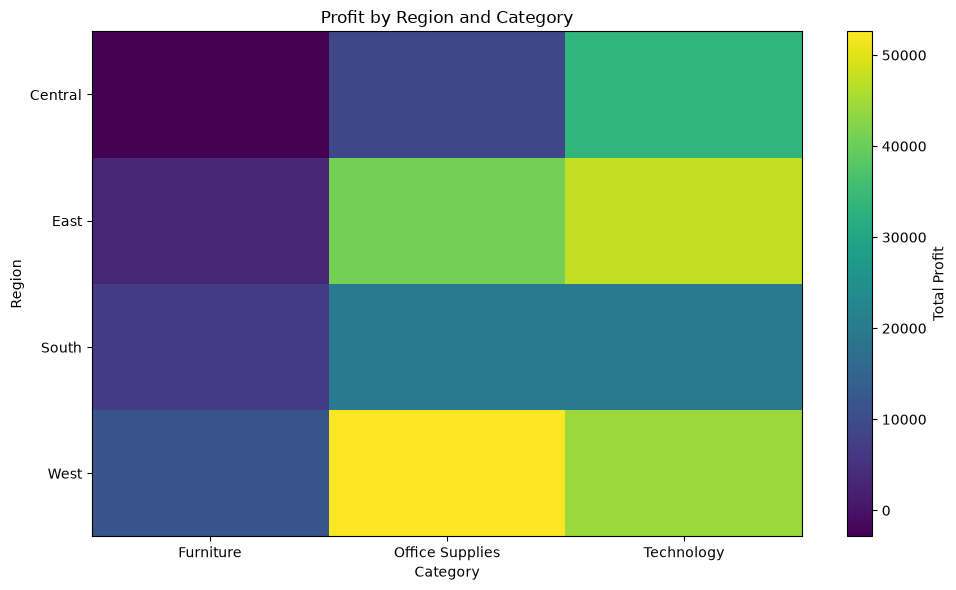

In [42]:
plot_profit_by_region_category(
    analysis_results["profit_by_region_category"]
)